# ECCB 2026 regulatory annotation tutorial - Python / PyRanges.


## Overview

This notebook provides a practical workflow for exploring cis-regulatory annotations and open chromatin evidence tracks in specific genomic regions.

It:

- Downloads example regulatory annotation and open-chromatin datasets.
- Reads ENCODE candidate cis-regulatory elements (cCREs), Ensembl Regulatory Features, and HCT116 ATAC-seq and DNase-seq peaks.
- Standardizes chromosome names and harmonizes the input data.
- Summarizes and compares regulatory feature types from ENCODE and Ensembl.
- Identifies regulatory features overlapping the selected query regions.
- Combines the annotation sources into a single table.
- Selects and exports promoter-like features and identifies active promoters supported by open-chromatin evidence in HCT116.
- Produces summary tables, plots, and output files for downstream analysis.

## Import and install python packages

In [1]:
from __future__ import annotations

import importlib.util
import os
import re
import subprocess
import sys
from pathlib import Path
import gzip
import shutil
from pathlib import Path
import rpy2.robjects as ro

### Installing required libraries

The first execution of this notebook may take 5–10 minutes, as several python libraries (including their dependencies) need to be installed. This step only needs to be completed once per Colab session.



In [2]:
def install_if_missing(packages: dict[str, str], upgrade_pip: bool = True) -> None:
    """Install packages that are usually missing from a fresh Colab runtime."""
    if upgrade_pip:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "--disable-pip-version-check",
                "install",
                "-q",
                "--upgrade",
                "pip",
            ]
        )

    missing = [
        package_name
        for module_name, package_name in packages.items()
        if importlib.util.find_spec(module_name) is None
    ]

    if missing:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "--disable-pip-version-check",
                "install",
                "-q",
                *missing,
            ]
        )


install_if_missing(
    {
        "pandas": "pandas",
        "pyranges": "pyranges",
        "gffutils": "gffutils",
        "matplotlib": "matplotlib",
        "seaborn": "seaborn"
    }
)


### Importing specific libraries:

In [3]:
import gffutils
import matplotlib.pyplot as plt
import pandas as pd
import pyranges as pr
import seaborn as sns

## Downloading input files

In [4]:

# -----------------------------------------------------------------------------
# Detect Google Colab
# -----------------------------------------------------------------------------

try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

# -----------------------------------------------------------------------------
# Download from EBI GitLab
# -----------------------------------------------------------------------------

download_file = ro.r["download.file"]


def download_from_gitlab(url: str, outfile: Path) -> None:
    """Download a public GitLab file using R's download.file()."""
    outfile.parent.mkdir(parents=True, exist_ok=True)

    result = download_file(
        url,
        str(outfile),
        mode="wb",
        quiet=True,
    )

    if int(result[0]) != 0:
        raise RuntimeError(f"Failed to download: {url}")


# -----------------------------------------------------------------------------
# Setup
# -----------------------------------------------------------------------------

try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:

    print("Google Colab detected.")

    workdir = Path("/content/ECCB2026")
    data_dir = workdir / "data"

    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = (
        "https://gitlab.ebi.ac.uk/ensembl-regulation/ECCB-2026-T6/-/raw/main/data/"
    )
    files = [
    "query_regions/custom_loci_GRCh38.bed",
    "cres_annotation/ENCODE/GRCh38-cCRE-colors18062026.bed.gz",
    "cres_annotation/ENCODE/HCT116-cCRE.chr8.bed",
    "cres_annotation/Ensembl_Regulation/Homo_sapiens.GRCh38.regulatory_features.v116.gff3.gz",
    "evidence/ENCODE/HCT116/ENCFF240LRP.dnase.bed",
    "evidence/ENCODE/HCT116/ENCFF296ZZB.atac.bed",
    "evidence/Ensembl_Regulation/HCT116/dnase_seq_hct116_m_48_y.bed.gz",
    "evidence/Ensembl_Regulation/HCT116/atac_seq_hct116_m_48_y.bed.gz"
    ]

    for f in files:

        outfile = data_dir / Path(f).name

        if not outfile.exists():

            url = base_url + f

            print(f"Downloading {outfile.name}")
            download_from_gitlab(url, outfile)


else:

    workdir = Path.cwd().parent
    data_dir = workdir / "data"

Google Colab detected.


 Decompress *gz files

In [5]:
gz_files = list(data_dir.glob("*.gz"))

for file in gz_files:
    with gzip.open(file, "rb") as fin:
        with open(file.with_suffix(""), "wb") as fout:
            shutil.copyfileobj(fin, fout)

### Paths definition

In [6]:
paths = {
    "encode_cre_bed": data_dir / "GRCh38-cCRE-colors18062026.bed",
    "ensembl_cre_gff3": data_dir / "Homo_sapiens.GRCh38.regulatory_features.v116.gff3",
    "query_regions_bed": data_dir / "custom_loci_GRCh38.bed",
    "encode_atac": data_dir / "ENCFF296ZZB.atac.bed",
    "encode_dnase": data_dir / "ENCFF240LRP.dnase.bed",
    "ensembl_atac": data_dir / "atac_seq_hct116_m_48_y.bed",
    "ensembl_dnase": data_dir / "dnase_seq_hct116_m_48_y.bed",
    "output_dir": workdir / "outputs" / "Python",
}

paths["output_dir"].mkdir(parents=True, exist_ok=True)

required_paths = [
    paths["encode_cre_bed"],
    paths["ensembl_cre_gff3"],
    paths["query_regions_bed"],
    paths["ensembl_atac"],
    paths["ensembl_dnase"],
    paths["encode_atac"],
    paths["encode_dnase"],
]
missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(
        "Missing required input path(s):\n"
        f"{missing_text}\n\n"
        f"Current working directory: {Path.cwd()}\n"
        f"Project root used by this script: {workdir}\n\n"
        "If this is not the Tutorial_material folder, set it first, for example:\n"
        'os.environ["TUTORIAL_ROOT"] = "/path/to/Tutorial_material"'
    )

print(f"Project root: {workdir}")
print("Input paths")
for label, path in paths.items():
    print(f"{label}: {path}")



Project root: /content/ECCB2026
Input paths
encode_cre_bed: /content/ECCB2026/data/GRCh38-cCRE-colors18062026.bed
ensembl_cre_gff3: /content/ECCB2026/data/Homo_sapiens.GRCh38.regulatory_features.v116.gff3
query_regions_bed: /content/ECCB2026/data/custom_loci_GRCh38.bed
encode_atac: /content/ECCB2026/data/ENCFF296ZZB.atac.bed
encode_dnase: /content/ECCB2026/data/ENCFF240LRP.dnase.bed
ensembl_atac: /content/ECCB2026/data/atac_seq_hct116_m_48_y.bed
ensembl_dnase: /content/ECCB2026/data/dnase_seq_hct116_m_48_y.bed
output_dir: /content/ECCB2026/outputs/Python


## Helpers
### File readers

In [7]:
def read_bed_table(path: Path, column_names: list[str]) -> pd.DataFrame:
    """Read BED-like files while keeping only the columns needed for the tutorial."""
    bed = pd.read_csv(
        path,
        sep="\t",
        header=None,
        comment="#",
        usecols=list(range(len(column_names))),
        names=column_names, low_memory = False
    )
    # We will use 'Chromosome', 'Start', and 'End' for compatibility with PyRanges
    bed["Chromosome"] = bed["Chromosome"].astype(str)
    bed["Start"] = pd.to_numeric(bed["Start"], errors="raise").astype(int)
    bed["End"] = pd.to_numeric(bed["End"], errors="raise").astype(int)

    if (bed["Start"] >= bed["End"]).any():
        raise ValueError(f"BED Start must be smaller than End in: {path}")

    return bed

In [8]:
def read_ensembl_gff3(path: Path) -> pd.DataFrame:
    """Read Ensembl Regulatory Features GFF3 and keep attributes as columns."""
    db = gffutils.create_db(
        str(path),
        dbfn=":memory:",
        force=True,
        keep_order=True,
        merge_strategy="create_unique",
        sort_attribute_values=False,
        disable_infer_genes=True,
        disable_infer_transcripts=True,
    )

    records = []
    for feature in db.all_features(order_by=("seqid", "start")):
        attributes = {key: ",".join(values) for key, values in feature.attributes.items()}
        attributes.setdefault("ID", feature.id)

        row = {
            "Chromosome": feature.seqid,
            "Start": int(feature.start) - 1,
            "End": int(feature.end),
            "strand": feature.strand,
            "type": feature.featuretype,
        }

        for key, value in attributes.items():
            column = key if key not in row else f"attribute_{key}"
            row[column] = value

        records.append(row)

    return pd.DataFrame(records)



### Chromosome names harmonization

In [9]:
def harmonize_seqnames(df: pd.DataFrame) -> pd.DataFrame:
    """Match the R script by removing the chr prefix from chromosome names."""
    out = df.copy()
    out["Chromosome"] = out["Chromosome"].astype(str).map(
        lambda value: re.sub(r"^chr", "", value)
    )
    return out


### Combination of open chromatin tracks

In [10]:
def make_open_chromatin_union(
    atac_df: pd.DataFrame,
    dnase_df: pd.DataFrame,
    evidence_source: str,
) -> pd.DataFrame:
    peaks = pd.concat(
        [
            atac_df[["Chromosome", "Start", "End"]],
            dnase_df[["Chromosome", "Start", "End"]],
        ],
        ignore_index=True,
    )

    union_df = pr.PyRanges(peaks).merge().df
    union_df["evidence_source"] = evidence_source
    union_df["assays"] = "ATAC-seq + DNase-seq"
    union_df["union_peak_id"] = [
        f"{evidence_source}_union_peak_{i}" for i in range(1, len(union_df) + 1)
    ]

    return union_df



## Processing
### Read input files

In [11]:
# ENCODE cCREs
ENCODE_cCREs = read_bed_table(
    paths["encode_cre_bed"],
    ["Chromosome", "Start", "End", "name", "score", "strand", "thickStart",
     "thickEnd", "color", "type"]
)
ENCODE_cCREs["source"] = "ENCODE"

print("\nENCODE cCREs")
print(ENCODE_cCREs.head())



ENCODE cCREs
  Chromosome  Start    End          name  score strand  thickStart  thickEnd  \
0       chr1  10385  10713  EH38E2776517      0      .       10385     10713   
1       chr1  16097  16381  EH38E3951272      0      .       16097     16381   
2       chr1  17343  17642  EH38E3951273      0      .       17343     17642   
3       chr1  29320  29517  EH38E3951274      0      .       29320     29517   
4       chr1  66350  66509  EH38E3951275      0      .       66350     66509   

        color     type  source  
0   255,167,0     pELS  ENCODE  
1   0,176,240  CA-CTCF  ENCODE  
2  190,40,229    CA-TF  ENCODE  
3   6,218,147       CA  ENCODE  
4   6,218,147       CA  ENCODE  


In [12]:
# Ensembl Regulation Regulatory Features
EnsRegRFs = read_ensembl_gff3(paths["ensembl_cre_gff3"])
EnsRegRFs["source"] = "Ensembl"

print("\nEnsembl Regulatory Features")
print(EnsRegRFs.head())


Ensembl Regulatory Features
  Chromosome  Start    End strand               type          ID  \
0          1  10935  11436      .           promoter   ENSR1_958   
1          1  11221  11243      +  CTCF_binding_site  ENSR1_53X2   
2          1  11279  11301      +  CTCF_binding_site  ENSR1_53X9   
3          1  11338  11360      +  CTCF_binding_site  ENSR1_53XJ   
4          1  11436  11649      .           enhancer   ENSR1_88N   

  extended_start extended_end          gene_id gene_name gene_biotype  \
0           9953        11436  ENSG00000290825  DDX11L16       lncRNA   
1            NaN          NaN              NaN       NaN          NaN   
2            NaN          NaN              NaN       NaN          NaN   
3            NaN          NaN              NaN       NaN          NaN   
4            NaN          NaN              NaN       NaN          NaN   

     color   source  
0  #ff0000  Ensembl  
1  #40e0d0  Ensembl  
2  #40e0d0  Ensembl  
3  #40e0d0  Ensembl  
4  #faca00  E

In [13]:
# User-defined query regions
query_regions = read_bed_table(
    paths["query_regions_bed"],
    ["Chromosome", "Start", "End", "region"],
)
print(query_regions.head())

  Chromosome      Start        End                                region
0       chr8  127719385  127750748  query_region_1_8_127719386_127750748
1       chr8  127394141  127410068  query_region_2_8_127394142_127410068


In [14]:
# HCT116 open chromatin evidence files from Ensembl Regulation
ensembl_atac = read_bed_table(
    paths["ensembl_atac"],
    ["Chromosome", "Start", "End"],
)
ensembl_atac["evidence_source"] = "Ensembl HCT116"
ensembl_atac["assay"] = "ATAC-seq"

ensembl_dnase = read_bed_table(
    paths["ensembl_dnase"],
    ["Chromosome", "Start", "End"],
)
ensembl_dnase["evidence_source"] = "Ensembl HCT116"
ensembl_dnase["assay"] = "DNase-seq"

# HCT116 open chromatin evidence files from ENCODE
encode_atac = read_bed_table(
    paths["encode_atac"],
    ["Chromosome", "Start", "End"],
)
encode_atac["evidence_source"] = "ENCODE HCT116"
encode_atac["assay"] = "ATAC-seq"

encode_dnase = read_bed_table(
    paths["encode_dnase"],
    ["Chromosome", "Start", "End"],
)
encode_dnase["evidence_source"] = "ENCODE HCT116"
encode_dnase["assay"] = "DNase-seq"


### Standardizing chromosome names

In [15]:
ENCODE_cCREs = harmonize_seqnames(ENCODE_cCREs)
EnsRegRFs = harmonize_seqnames(EnsRegRFs)
query_regions = harmonize_seqnames(query_regions)
ensembl_atac = harmonize_seqnames(ensembl_atac)
ensembl_dnase = harmonize_seqnames(ensembl_dnase)
encode_atac = harmonize_seqnames(encode_atac)
encode_dnase = harmonize_seqnames(encode_dnase)


### Inspect datasets

In [16]:
print("\nENCODE cCRE feature counts")
print(ENCODE_cCREs.groupby("type").size().reset_index(name="n"))



ENCODE cCRE feature counts
         type        n
0          CA   245985
1     CA-CTCF   126034
2  CA-H3K4me3    79246
3       CA-TF    26102
4         PLS    47532
5          TF   105286
6        dELS  1469205
7        pELS   249463


In [17]:
print("\nEnsembl Regulatory Feature counts")
print(EnsRegRFs.groupby("type").size().reset_index(name="n"))



Ensembl Regulatory Feature counts
                    type       n
0      CTCF_binding_site   90891
1               enhancer  246403
2  open_chromatin_region    7541
3               promoter   35983


In [18]:
unified_cre_type = {
    "promoter": "promoter",
    "PLS": "promoter",
    "CA-H3K4me3": "CA-H3K4me3",
    "enhancer": "enhancer",
    "pELS": "enhancer",
    "dELS": "enhancer",
    "open_chromatin_region": "open chromatin",
    "CA": "open chromatin",
    "TF": "TF BS",
    "CA-TF": "TF BS",
    "CA-CTCF": "CTCF BS",
    "CTCF_binding_site": "CTCF BS",
}

ccres_colors = {
    "open chromatin": "#06da93",
    "CTCF BS": "#00b0f0",
    "CA-H3K4me3": "#ffaaaa",
    "TF BS": "#be28e5",
    "enhancer": "#ffa700",
    "promoter": "#ff0000",
    "other": "#999999",
}


### Percentage of feature type per dataset

In [19]:
feature_summary = pd.concat(
    [
        (
            ENCODE_cCREs.groupby("type")
            .size()
            .reset_index(name="n")
            .assign(source="ENCODE cCREs", percent=lambda x: x["n"] / len(ENCODE_cCREs) * 100)
        ),
        (
            EnsRegRFs.groupby("type")
            .size()
            .reset_index(name="n")
            .assign(source="Ensembl RFs", percent=lambda x: x["n"] / len(EnsRegRFs) * 100)
        ),
    ],
    ignore_index=True,
)
feature_summary["unified_type"] = feature_summary["type"].map(unified_cre_type).fillna("other")
type_order = [
    "promoter",
    "PLS",
    "CA-H3K4me3",
    "pELS",
    "dELS",
    "enhancer",
    "CA",
    "open chromatin",
    "open_chromatin_region",
    "CTCF_binding_site",
    "CA-CTCF",
    "CA-TF",
    "TF",
]


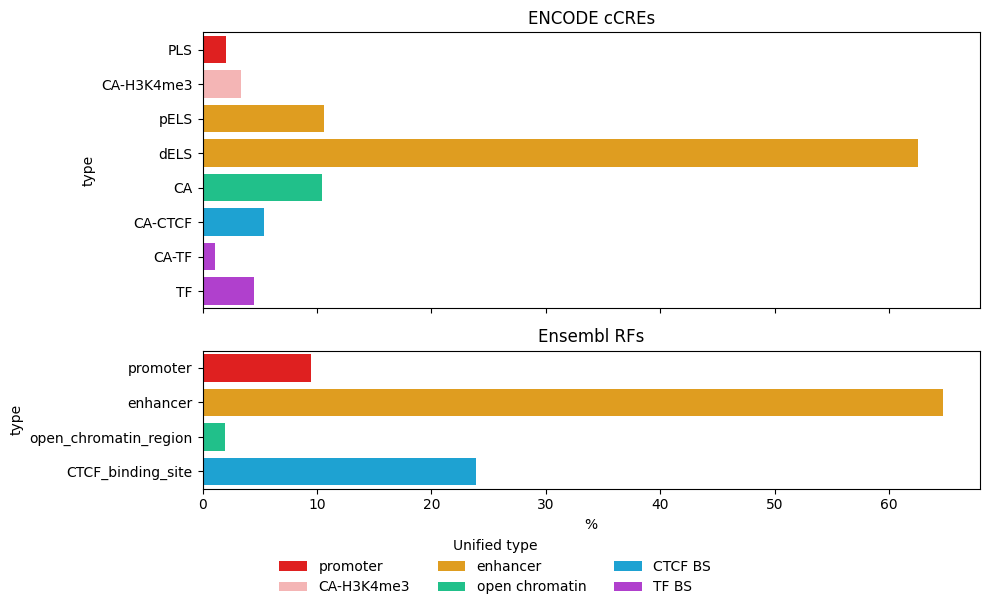

In [20]:
hue_order = [
    "promoter",
    "CA-H3K4me3",
    "enhancer",
    "open chromatin",
    "CTCF BS",
    "TF BS",
]


n1 = len(feature_summary.query("source == 'ENCODE cCREs'"))
n2 = len(feature_summary.query("source == 'Ensembl RFs'"))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [n1, n2]},
)

for ax, source in zip(axes, feature_summary["source"].unique()):

    df = feature_summary.query("source == @source").copy()

    order = [x for x in type_order if x in df["type"].values]

    sns.barplot(
        data=df,
        x="percent",
        y="type",
        hue="unified_type",
        order=order,
        hue_order=hue_order,
        palette=ccres_colors,
        ax=ax,
    )

    ax.set_title(source)
    ax.set_xlabel("")

# Get legend from first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from all subplots
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()

# Add one shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    title="Unified type",
    frameon=False,
)

axes[-1].set_xlabel("%")

plt.tight_layout(rect=[0, 0.08, 1, 1])



### Combine open chromatin peaks for defining regulatory activity

In [21]:
ensembl_open_union = make_open_chromatin_union(
    ensembl_atac,
    ensembl_dnase,
    "Ensembl HCT116",
)

print("\nEnsembl open chromatin union")
print(ensembl_open_union.head())




Ensembl open chromatin union
  Chromosome  Start    End evidence_source                assays  \
0          1   9957  10649  Ensembl HCT116  ATAC-seq + DNase-seq   
1          1  10908  11529  Ensembl HCT116  ATAC-seq + DNase-seq   
2          1  15534  15764  Ensembl HCT116  ATAC-seq + DNase-seq   
3          1  26017  26324  Ensembl HCT116  ATAC-seq + DNase-seq   
4          1  28657  30149  Ensembl HCT116  ATAC-seq + DNase-seq   

                 union_peak_id  
0  Ensembl HCT116_union_peak_1  
1  Ensembl HCT116_union_peak_2  
2  Ensembl HCT116_union_peak_3  
3  Ensembl HCT116_union_peak_4  
4  Ensembl HCT116_union_peak_5  


In [22]:
encode_open_union = make_open_chromatin_union(
    encode_atac,
    encode_dnase,
    "ENCODE HCT116",
)

print("\nENCODE open chromatin union")
print(encode_open_union.head())



ENCODE open chromatin union
  Chromosome   Start     End evidence_source                assays  \
0          1   10256   10645   ENCODE HCT116  ATAC-seq + DNase-seq   
1          1  180904  181984   ENCODE HCT116  ATAC-seq + DNase-seq   
2          1  196420  196685   ENCODE HCT116  ATAC-seq + DNase-seq   
3          1  268011  268080   ENCODE HCT116  ATAC-seq + DNase-seq   
4          1  778323  779232   ENCODE HCT116  ATAC-seq + DNase-seq   

                union_peak_id  
0  ENCODE HCT116_union_peak_1  
1  ENCODE HCT116_union_peak_2  
2  ENCODE HCT116_union_peak_3  
3  ENCODE HCT116_union_peak_4  
4  ENCODE HCT116_union_peak_5  


### Identify features in the query regions

In [23]:
ENCODE_cCREs_in_query = pr.PyRanges(ENCODE_cCREs).join(
    pr.PyRanges(query_regions),
    suffix="_query",
).df
ENCODE_cCREs_in_query["unified_type"] = (
    ENCODE_cCREs_in_query["type"].map(unified_cre_type).fillna("other")
)

EnsRegRFs_in_query = pr.PyRanges(EnsRegRFs).join(
    pr.PyRanges(query_regions),
    suffix="_query",
).df
EnsRegRFs_in_query["unified_type"] = (
    EnsRegRFs_in_query["type"].map(unified_cre_type).fillna("other")
)


In [24]:
print("\nENCODE cCREs in query regions")
print(ENCODE_cCREs_in_query.groupby("region").size().reset_index(name="n"))



ENCODE cCREs in query regions
                                 region   n
0  query_region_1_8_127719386_127750748  66
1  query_region_2_8_127394142_127410068  30


In [25]:
print("\nEnsembl Regulatory Features in query regions")
print(EnsRegRFs_in_query.groupby("region").size().reset_index(name="n"))



Ensembl Regulatory Features in query regions
                                 region   n
0  query_region_1_8_127719386_127750748  21
1  query_region_2_8_127394142_127410068   7


In [26]:
CREs_in_query = pd.concat(
    [
        ENCODE_cCREs_in_query[
            ["Chromosome", "Start", "End", "name", "type", "unified_type", "region"]
        ].assign(source="ENCODE"),
        EnsRegRFs_in_query.assign(name=EnsRegRFs_in_query["ID"])[
            ["Chromosome", "Start", "End", "name", "type", "unified_type", "region"]
        ].assign(source="Ensembl"),
    ],
    ignore_index=True,
)

query_feature_summary = (
    CREs_in_query.groupby(["source", "region", "unified_type", "type"])
    .size()
    .reset_index(name="n")
)

print("\nCREs in query regions")
print(query_feature_summary)


CREs in query regions
     source                                region    unified_type  \
0    ENCODE  query_region_1_8_127719386_127750748      CA-H3K4me3   
1    ENCODE  query_region_1_8_127719386_127750748         CTCF BS   
2    ENCODE  query_region_1_8_127719386_127750748           TF BS   
3    ENCODE  query_region_1_8_127719386_127750748           TF BS   
4    ENCODE  query_region_1_8_127719386_127750748        enhancer   
5    ENCODE  query_region_1_8_127719386_127750748        enhancer   
6    ENCODE  query_region_1_8_127719386_127750748  open chromatin   
7    ENCODE  query_region_1_8_127719386_127750748        promoter   
8    ENCODE  query_region_2_8_127394142_127410068         CTCF BS   
9    ENCODE  query_region_2_8_127394142_127410068           TF BS   
10   ENCODE  query_region_2_8_127394142_127410068        enhancer   
11   ENCODE  query_region_2_8_127394142_127410068        enhancer   
12   ENCODE  query_region_2_8_127394142_127410068        promoter   
13  Ensembl

### Number of features in the query regions

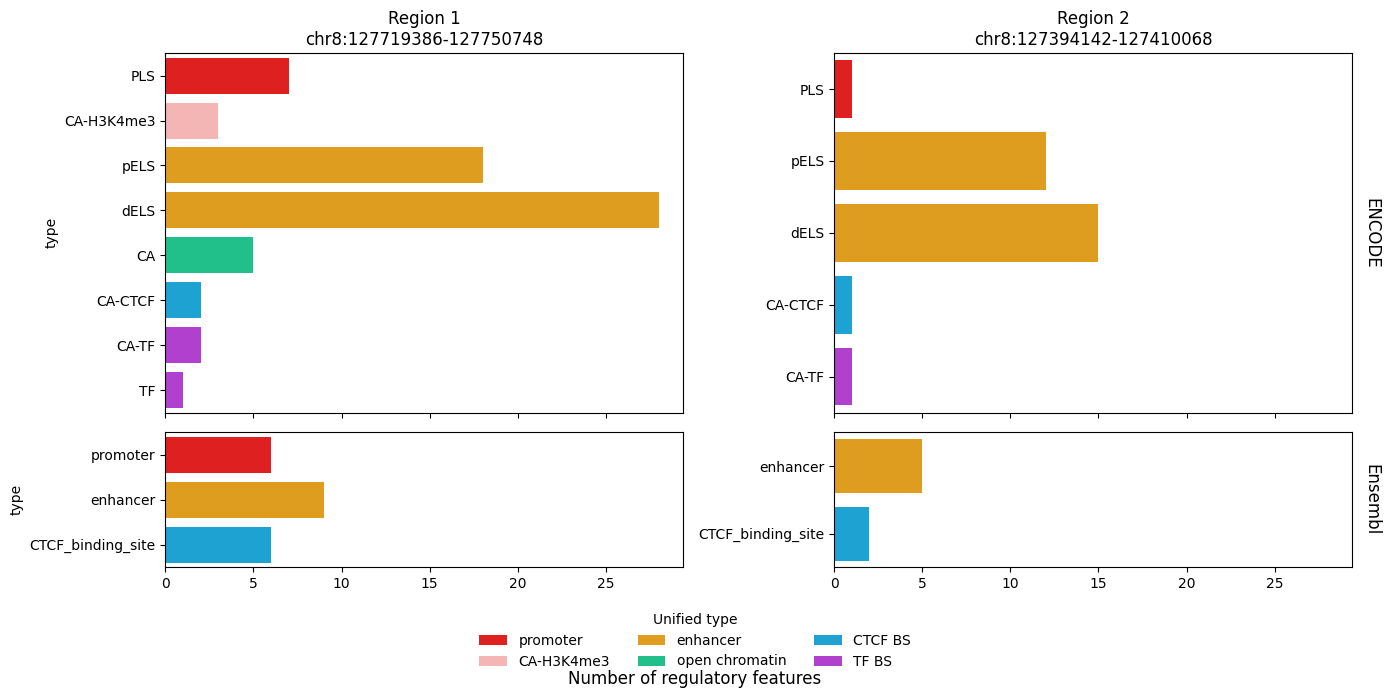

In [27]:
query_feature_summary["region_label"] = query_feature_summary["region"].str.replace(
    r"^query_region_(\d+)_(.+)_(\d+)_(\d+)$",
    r"Region \1\nchr\2:\3-\4",
    regex=True,
)

sources = ["ENCODE", "Ensembl"]
regions = query_feature_summary["region_label"].drop_duplicates().tolist()

height_ratios = [
    query_feature_summary.query("source == @source")["type"].nunique()
    for source in sources
]

fig, axes = plt.subplots(
    nrows=len(sources),
    ncols=len(regions),
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)

# Make sure axes is always 2D
if len(sources) == 1:
    axes = axes.reshape(1, -1)

for i, source in enumerate(sources):

    for j, region in enumerate(regions):

        ax = axes[i, j]

        df = query_feature_summary.query(
            "source == @source & region_label == @region"
        ).copy()

        order = [x for x in type_order if x in df["type"].values]

        sns.barplot(
            data=df,
            x="n",
            y="type",
            hue="unified_type",
            order=order,
            hue_order=hue_order,
            palette=ccres_colors,
            width=0.8,
            ax=ax,
        )

        # Titles only on first row
        if i == 0:
            ax.set_title(region)

        # Source labels on the right
        if j == len(regions) - 1:
            ax.annotate(
                source,
                xy=(1.02, 0.5),
                xycoords="axes fraction",
                rotation=-90,
                va="center",
                ha="left",
                fontsize=12,
            )

        # Only left column gets y-axis label
        if j == 0:
            ax.set_ylabel("type")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

        # Remove individual legends
        if ax.legend_ is not None:
            ax.legend_.remove()

# Shared legend

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    title="Unified type",
    frameon=False,
)

# Shared x-axis label
fig.supxlabel("Number of regulatory features")

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

### Selecting promoters in the query regions

In [28]:
selected_feature_types = ["promoter", "PLS"]
promoters_in_query = CREs_in_query[CREs_in_query["type"].isin(selected_feature_types)].copy()

print("\nPromoter-like CREs in query regions")
print(promoters_in_query)



Promoter-like CREs in query regions
    Chromosome      Start        End          name      type unified_type  \
12           8  127400342  127400576  EH38E3858445       PLS     promoter   
53           8  127733989  127734338  EH38E3858721       PLS     promoter   
56           8  127735099  127735447  EH38E3858722       PLS     promoter   
57           8  127735611  127735762  EH38E3858723       PLS     promoter   
58           8  127735819  127736017  EH38E3858724       PLS     promoter   
59           8  127736051  127736398  EH38E3858725       PLS     promoter   
63           8  127737299  127737554  EH38E3858729       PLS     promoter   
68           8  127738862  127739018  EH38E3858734       PLS     promoter   
109          8  127733945  127734457   ENSR8_BXCG3  promoter     promoter   
111          8  127735248  127735669  ENSR8_93TNWH  promoter     promoter   
112          8  127735794  127736241  ENSR8_93TNWM  promoter     promoter   
113          8  127736467  127736968  E

### Identifying active promoters in HCT116

In [29]:
ENCODE_promoters_in_query = promoters_in_query[promoters_in_query["source"] == "ENCODE"]
EnsReg_promoters_in_query = promoters_in_query[promoters_in_query["source"] == "Ensembl"]

if ENCODE_promoters_in_query.empty:
    active_ENCODE_promoters = ENCODE_promoters_in_query
else:
    ENCODE_promoter_hits = pr.PyRanges(ENCODE_promoters_in_query).join(
        pr.PyRanges(encode_open_union),
        suffix="_open",
    ).df
    active_ENCODE_names = (
        ENCODE_promoter_hits["name"].drop_duplicates()
        if "name" in ENCODE_promoter_hits
        else []
    )
    active_ENCODE_promoters = ENCODE_promoters_in_query[
        ENCODE_promoters_in_query["name"].isin(active_ENCODE_names)
    ]

if EnsReg_promoters_in_query.empty:
    active_Ensembl_promoters = EnsReg_promoters_in_query
else:
    EnsReg_promoter_hits = pr.PyRanges(EnsReg_promoters_in_query).join(
        pr.PyRanges(ensembl_open_union),
        suffix="_open",
    ).df
    active_Ensembl_names = (
        EnsReg_promoter_hits["name"].drop_duplicates()
        if "name" in EnsReg_promoter_hits
        else []
    )
    active_Ensembl_promoters = EnsReg_promoters_in_query[
        EnsReg_promoters_in_query["name"].isin(active_Ensembl_names)
    ]

active_promoters_in_query = pd.concat(
    [active_ENCODE_promoters, active_Ensembl_promoters],
    ignore_index=True,
).drop_duplicates()

print("\nActive promoter-like CREs in query regions")
print(active_promoters_in_query)




Active promoter-like CREs in query regions
   Chromosome      Start        End          name      type unified_type  \
0           8  127400342  127400576  EH38E3858445       PLS     promoter   
1           8  127733989  127734338  EH38E3858721       PLS     promoter   
2           8  127735099  127735447  EH38E3858722       PLS     promoter   
3           8  127735611  127735762  EH38E3858723       PLS     promoter   
4           8  127735819  127736017  EH38E3858724       PLS     promoter   
5           8  127736051  127736398  EH38E3858725       PLS     promoter   
6           8  127733945  127734457   ENSR8_BXCG3  promoter     promoter   
7           8  127735248  127735669  ENSR8_93TNWH  promoter     promoter   
8           8  127735794  127736241  ENSR8_93TNWM  promoter     promoter   
9           8  127736467  127736968  ENSR8_93TNWT  promoter     promoter   
10          8  127737130  127737755   ENSR8_BXCGJ  promoter     promoter   
11          8  127738266  127738767  ENSR8_9

### Saving output files

In [30]:
active_promoters_in_query[
    ["Chromosome", "Start", "End", "name", "type", "source", "region"]
].to_csv(
    paths["output_dir"] / "hct116_active_promoters_python.bed",
    sep="\t",
    index=False,
    header=False,
)

print(f"\nOutputs written to: {paths['output_dir']}")



Outputs written to: /content/ECCB2026/outputs/Python
